In [13]:
# Importamos las librerias
import numpy as np          # Import NumPy for numerical operations and array handling
from PIL import Image      # Import PIL (Python Imaging Library) for image processing
import scipy.io as sio     # Import SciPy's IO module for reading .mat files
import matplotlib.pyplot as plt #Import Matplotlib 
import os  

def cargar_imagenes(category):

    # Definimos tamaño objeto
    obj_resize = (256,256)

    ruta = './data/WillowObject/WILLOW-ObjectClass/' + category

    #Definimos las listas donde vamos a guardar los distintos elementos
    pngs = []
    mats = []
    imgs = []
    kpts_list = []
    
    # Recorremos directorio indicado
    # Guardamos los archivos png y mat en dos listas separadas (pero ordenadas)
    for img in os.listdir(ruta):
        if img.endswith('.png'):
            pngs.append(img)
        elif img.endswith('.mat'):
            mats.append(img)

    pngs = sorted(pngs)
    mats = sorted(mats)

    # Ya tenemos los pngs y mats guardados en listas
    for i in range(8):
        img = Image.open(ruta + '/' + pngs[i])
        kpts = np.array(sio.loadmat(ruta + '/' + mats[i])['pts_coord'])

        kpts[0] = kpts[0] * obj_resize[0] / img.size[0]
        kpts[1] = kpts[1] * obj_resize[1] / img.size[1]

        img = img.resize(obj_resize, resample=Image.BILINEAR)

        kpts_list.append(kpts)
        imgs.append(img)

    # Devolvemos los valores para poder usar la otra función

    return imgs, kpts_list

In [19]:
def delaunay_graph(kpts):
    """Constructs a Delaunay triangulation graph from keypoints."""
    # Implement Delaunay triangulation
    pts = kpts.T
    tri = Delaunay(pts)        
    edges = set()
    for tri in tri.simplices:
        cat1, cat2, cat3 = tri
        edges.add(tuple(sorted((cat1, cat2))))
        edges.add(tuple(sorted((cat2, cat3))))
        edges.add(tuple(sorted((cat1, cat3))))
        
    return list(edges)

In [ ]:
import math 

def knn_graph(kpts, k):
    """Constructs a k-NN graph from keypoints."""
    # Implement k-NN graph construction
    pts = kpts.T
    distancias_euclidianas = []
    sumatorio = 0
    # Vamos a separa la lista de keypoints, en una lista que vaya 
    # de 2 keypoints en 2

    # Calculamos las distancias euclidianas
    for i in range(len(pts)):
        for punto in kpts[i]:
            sumatorio = 0
            sumatorio += ((punto[1]-punto[0])^2+()^2)
            distancias_euclidianas.append(math.sqrt(sumatorio))   

    # Para cada punto clave, seleccionamos los vecinos más cercanos
    edges = set()

    distancias_euclidianas = sorted(distancias_euclidianas)
    for dist in distancias_euclidianas:

    # return list(edges)



SyntaxError: incomplete input (1070883381.py, line 24)

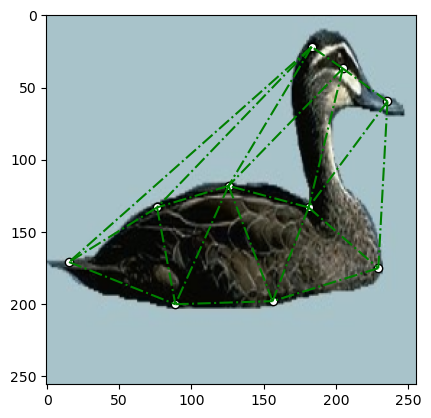

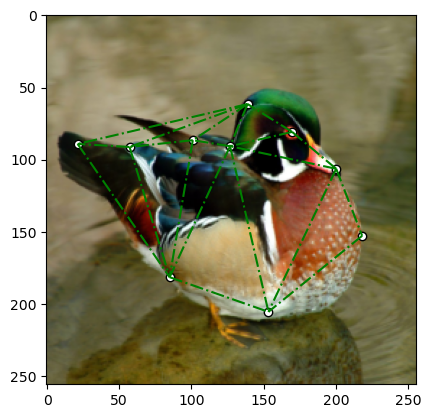

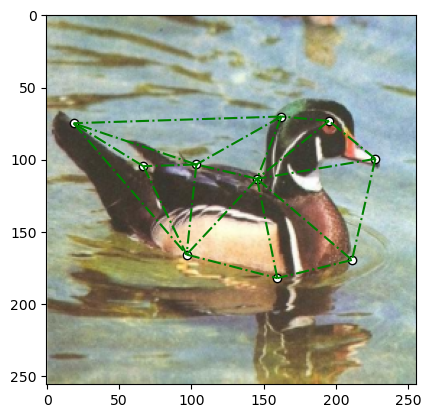

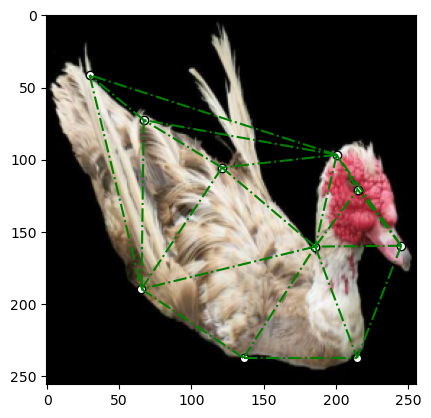

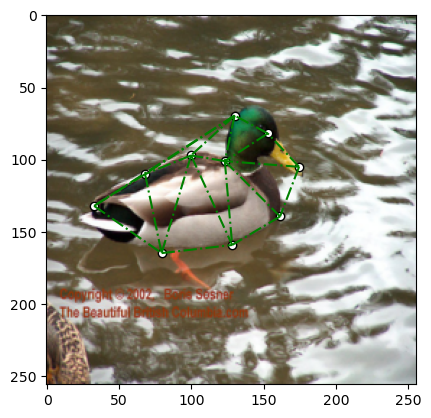

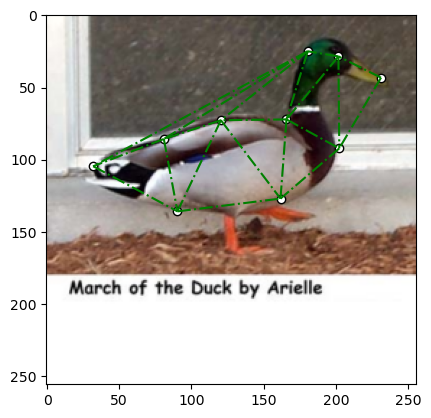

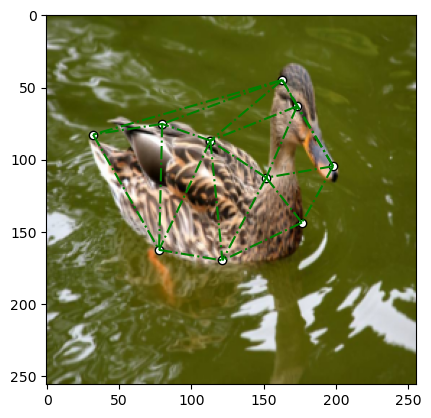

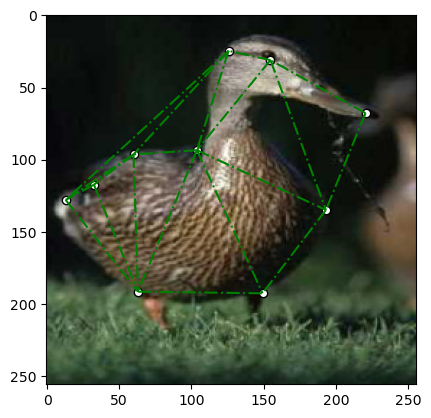

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
def plot_image_with_graph(img, kpt, edges):
    """
    Function to visualize an image with keypoints and graph edges
    
    Parameters:
    - img: Input image
    - kpt: Keypoints (2, N) array
    - edges: List of (i, j) tuples representing graph edges
    """
    plt.imshow(img)
    plt.scatter(kpt[0], kpt[1], c='w', edgecolors='k')
    
    for i, j in edges:
        plt.plot([kpt[0, i], kpt[0, j]], [kpt[1, i], kpt[1, j]], '-.g')
    plt.show()

img , kpt = cargar_imagenes('Duck')
for i in range(len(img)):
    edges = delaunay_graph(kpt[i])
    plot_image_with_graph(img[i],kpt[i],edges)
    
#end


In [36]:
imgs , kpts = cargar_imagenes('Duck')
pts = kpts[0].T
puntos = pts[0:4:]
print(pts)

[[235.77592077  59.57862158]
 [204.86784277  36.75968007]
 [183.27452801  21.78474971]
 [181.15753637 133.02708954]
 [229.42494584 175.09951294]
 [125.69235531 118.05215918]
 [ 76.15475085 133.02708954]
 [ 15.18539152 170.82096141]
 [ 88.85670071 200.05773021]
 [156.17703497 197.91845445]]


In [37]:
imgs , kpts = cargar_imagenes('Duck')
pts = kpts[0].T
puntos = pts[0:4:]
print(pts)

[[235.77592077  59.57862158]
 [204.86784277  36.75968007]
 [183.27452801  21.78474971]
 [181.15753637 133.02708954]
 [229.42494584 175.09951294]
 [125.69235531 118.05215918]
 [ 76.15475085 133.02708954]
 [ 15.18539152 170.82096141]
 [ 88.85670071 200.05773021]
 [156.17703497 197.91845445]]


In [ ]:
import math 

imgs, kpts = cargar_imagenes('Duck')
k = 3

def knn_graph(kpts, k):
    """Constructs a k-NN graph from keypoints."""
    # Implement k-NN graph construction
    pts = kpts.T
    lista_final = []

    # Calculamos las distancias euclidianas
    for i in range(len(pts)):
        punto = pts[i]
        for j in range(i+1, len(pts)):
            punto2 = pts[j]
            # distancia euclidiana correcta
            dist = math.sqrt((punto2[0] - punto[0])**2 + (punto2[1] - punto[1])**2)
            lista_final.append((dist, i, j))

    # Ya tenemos las distancias que hay entre cada punto clave
    edges = set()



    


    return lista_final

knn_graph(kpts[0], 3)

[(38.4189195147497, 0, 1),
 (64.68982139517811, 0, 2),
 (91.5305706374908, 0, 3),
 (115.69533795407528, 0, 4),
 (124.64969307736007, 0, 5),
 (175.70883680716827, 0, 6),
 (247.05270645221628, 0, 7),
 (203.27232272173637, 0, 8),
 (159.60542590360473, 0, 9),
 (26.277743088291153, 1, 2),
 (99.14430269111965, 1, 3),
 (140.50252904892645, 1, 4),
 (113.4778611667356, 1, 5),
 (160.73106158528321, 1, 6),
 (232.27539574233967, 1, 7),
 (200.31185252413854, 1, 8),
 (168.35363174476907, 1, 9),
 (111.26248165985689, 2, 3),
 (160.11020482865058, 2, 4),
 (112.1745102030164, 2, 5),
 (154.43284893453534, 2, 6),
 (224.64583282063404, 2, 7),
 (201.73245075727004, 2, 8),
 (178.20593725422333, 2, 9),
 (64.02992759347373, 3, 4),
 (57.45115185269982, 3, 5),
 (105.00278551532033, 3, 6),
 (170.22082603398445, 3, 7),
 (114.07256923103597, 3, 8),
 (69.53355081357404, 3, 9),
 (118.38433557265105, 4, 5),
 (158.93974166858618, 4, 6),
 (214.28227326914887, 4, 7),
 (142.76674734309188, 4, 8),
 (76.72001392882945, 4, 9